In [11]:
import numpy as np
import torch as th
import glob
import os, tqdm
from PIL import Image

def face_segment(segment_part, img):
    
    if isinstance(img, Image.Image):
        face_segment_anno = np.array(img)
    else:
        face_segment_anno = img
        
    bg = (face_segment_anno == 0)
    skin = (face_segment_anno == 1)
    l_brow = (face_segment_anno == 2)
    r_brow = (face_segment_anno == 3)
    l_eye = (face_segment_anno == 4)
    r_eye = (face_segment_anno == 5)
    eye_g = (face_segment_anno == 6)
    l_ear = (face_segment_anno == 7)
    r_ear = (face_segment_anno == 8)
    ear_r = (face_segment_anno == 9)
    nose = (face_segment_anno == 10)
    mouth = (face_segment_anno == 11)
    u_lip = (face_segment_anno == 12)
    l_lip = (face_segment_anno == 13)
    neck = (face_segment_anno == 14)
    neck_l = (face_segment_anno == 15)
    cloth = (face_segment_anno == 16)
    hair = (face_segment_anno == 17)
    hat = (face_segment_anno == 18)
    face = np.logical_or.reduce((skin, l_brow, r_brow, l_eye, r_eye, eye_g, l_ear, r_ear, ear_r, nose, mouth, u_lip, l_lip))
    foreground = face_segment_anno != 0

    if segment_part == 'faceseg_face':
        seg_m = face
    elif segment_part == 'faceseg_foreground':
        seg_m = foreground
    elif segment_part == 'faceseg_head':
        seg_m = (face | neck | hair)
    elif segment_part == 'faceseg_nohead':
        seg_m = ~(face | neck | hair)
    elif segment_part == 'faceseg_face&hair':
        seg_m = ~bg
    elif segment_part == 'faceseg_bg_noface&nohair':
        seg_m = (bg | hat | neck | neck_l | cloth) 
    elif segment_part == 'faceseg_bg&ears_noface&nohair':
        seg_m = (bg | hat | neck | neck_l | cloth) | (l_ear | r_ear | ear_r)
    elif segment_part == 'faceseg_bg':
        seg_m = bg
    elif segment_part == 'faceseg_bg&noface':
        seg_m = (bg | hair | hat | neck | neck_l | cloth)
    elif segment_part == 'faceseg_hair':
        seg_m = hair
    elif segment_part == 'faceseg_faceskin':
        seg_m = skin
    elif segment_part == 'faceseg_faceskin&nose':
        seg_m = (skin | nose)
    elif segment_part == 'faceseg_eyes&glasses&mouth&eyebrows':
        seg_m = (l_eye | r_eye | eye_g | l_brow | r_brow | mouth)
    elif segment_part == 'faceseg_faceskin&nose&mouth&eyebrows':
        seg_m = (skin | nose | mouth | u_lip | l_lip | l_brow | r_brow | l_eye | r_eye)
    elif segment_part == 'faceseg_faceskin&nose&mouth&eyebrows&eyes&glasses':
        seg_m = (skin | nose | mouth | u_lip | l_lip | l_brow | r_brow | l_eye | r_eye | eye_g)
    elif segment_part == 'faceseg_face_noglasses':
        seg_m = (~eye_g & face)
    elif segment_part == 'faceseg_face_noglasses_noeyes':
        seg_m = (~(l_eye | r_eye) & ~eye_g & face)
    elif segment_part == 'faceseg_eyes&glasses':
        seg_m = (l_eye | r_eye | eye_g)
    elif segment_part == 'glasses':
        seg_m = eye_g
    elif segment_part == 'faceseg_eyes':
        seg_m = (l_eye | r_eye)
    # elif (segment_part == 'sobel_bg_mask') or (segment_part == 'laplacian_bg_mask') or (segment_part == 'sobel_bin_bg_mask'):
    elif segment_part in ['sobel_bg_mask', 'laplacian_bg_mask', 'sobel_bin_bg_mask']:
        seg_m = ~(face | neck | hair)
    elif segment_part in ['canny_edge_bg_mask']:
        seg_m = ~(face | neck | hair) | (l_ear | r_ear)
    else: raise NotImplementedError(f"Segment part: {segment_part} is not found!")
    
    out = seg_m
    return out

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:13<00:00, 757.80it/s]


./pipeline/p2.jpg is most similar to /data/mint/DPM_Dataset/ffhq_256_with_anno/ffhq_256/valid/60577.jpg
[7675 8353  930 5512 4275 5751 6257 8846 4764 9703 5726 2319 4244  880
 4873 5402 7918 2418 9983 5111 1806 4806 2279 7695 6398]


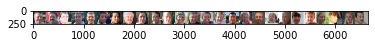

In [2]:
from PIL import Image
import numpy as np
import glob, tqdm, os
import matplotlib.pyplot as plt

# Find image by score
set_ = 'valid'
data_path = f'/data/mint/DPM_Dataset/ffhq_256_with_anno/ffhq_256/{set_}/'
mask_path = f'/data/mint/DPM_Dataset/ffhq_256_with_anno/face_segment/{set_}/anno/'

ffhq_imgs = glob.glob(f'{data_path}/*.jpg')

def cal_diff(img1, img2, mask=None):
    if mask is not None:
        # plt.imshow(mask[..., 0])
        # plt.show()
        # plt.imshow(np.array(img1))
        # plt.show()
        # plt.imshow(np.array(img2))
        # plt.show()
        # assert False
        return np.mean((np.array(img1) - np.array(img2))**2 * mask)
    else:
        return np.mean((np.array(img1) - np.array(img2))**2)

def cal_diff_face(img1, img2):
    # Focus on face region only (approximate face region on middle)
    img1 = np.array(img1)
    img2 = np.array(img2)
    img1 = img1[100:200, 100:200]
    img2 = img2[100:200, 100:200]
    return np.mean((img1 - img2)**2)

os.makedirs('./similar_ffhq_imgs', exist_ok=True)
# to_find_img = './difareli++_samples/*.png'
# to_find_img = './difareli_samples/*.png'
# to_find_img = './difareli_samples/*.jpg'
# to_find_img = './speedup_notuned_samples/*.jpg'
# to_find_img = './Holo_sj/No_match/*.png'
to_find_img = './pipeline/*.jpg'
sample_json = {}
for tfi in glob.glob(to_find_img):
    img_name = tfi.split('/')[-1].split('.')[0]
    tf_img = Image.open(tfi).convert('RGB').resize((256, 256))
    score = []
    for img in tqdm.tqdm(ffhq_imgs):
        # cmp_img_name = img.split('/')[-1].split('.')[0]
        img = Image.open(img)
        # mask = face_segment('faceseg_face', Image.open(mask_path + f'anno_{cmp_img_name}.png'))[..., None]
        score.append(cal_diff(tf_img, img, mask=None))
        
    idx = np.argmin(score)
    print(f'{tfi} is most similar to {ffhq_imgs[idx]}')
    # Show image and top 5 similar images
    show = [tf_img]
    for i in np.argsort(score)[:25]:
        img = Image.open(ffhq_imgs[i])
        show.append(img)
    show = np.hstack([np.array(img) for img in show])
    plt.imshow(show)
    print(np.argsort(score)[:25])
    plt.show()
    continue
    pair_idx = int(img_name.split('-')[0])
    src_dst_idx = int(img_name.split('-')[1])
    if f'pair{pair_idx-1}' not in sample_json:
        sample_json[f'pair{pair_idx-1}'] = {}
    sample_json[f'pair{pair_idx-1}'].update({'src': ffhq_imgs[idx]} if src_dst_idx == 1 else {'dst': ffhq_imgs[idx]})
    os.system(f'cp {ffhq_imgs[idx]} ./similar_ffhq_imgs/')
    
    

'/data/mint/DPM_Dataset/ffhq_256_with_anno/ffhq_256/train/11653.jpg'

In [7]:
sample_json_out = sample_json
for k, _ in sample_json_out.items():
    sample_json_out[k]['src'] = sample_json_out[k]['src'].split('/')[-1]
    sample_json_out[k]['dst'] = sample_json_out[k]['dst'].split('/')[-1]

sample_json_out = {'pair': sample_json_out}
print(sample_json_out)
import json
with open('./difareli++_samples.json', 'w') as f:
    json.dump(sample_json_out, f, indent=4)

{'pair': {'pair0': {'src': '62369.jpg', 'dst': '60438.jpg'}, 'pair2': {'dst': '67972.jpg', 'src': '60018.jpg'}, 'pair8': {'src': '60704.jpg', 'dst': '66496.jpg'}, 'pair1': {'src': '68105.jpg', 'dst': '69191.jpg'}, 'pair3': {'src': '62889.jpg', 'dst': '63966.jpg'}, 'pair7': {'src': '69128.jpg', 'dst': '65304.jpg'}, 'pair6': {'dst': '62962.jpg', 'src': '67313.jpg'}, 'pair10': {'src': '63023.jpg', 'dst': '60852.jpg'}, 'pair4': {'src': '68280.jpg', 'dst': '66149.jpg'}, 'pair9': {'dst': '66994.jpg', 'src': '62821.jpg'}, 'pair11': {'src': '69878.jpg', 'dst': '60022.jpg'}, 'pair5': {'dst': '63859.jpg', 'src': '65128.jpg'}}}
